
# Lab 8: Monte Carlo Markov Chain (MCMC)

## Modelo de Ising 2D

Como aplicación de la distribución canónica en `Física estadística` tenemos el modelo de **Ising**.

Para el caso de un material paramagnético de átomos de spin $1/2$ y momento magnetico $\mu_0$ en presencia de un campo magnético externo $H$, se ha determinado experimentalmente que la magnetización media depende del campo magnético y la temperatura del material. Consultar: (https://en.wikipedia.org/wiki/Ising_model)

**Exercise**: Considere un sistema compuesto por $N$ átomos no interactuantes en un material 2D, a una temperatura $T$ y en presencia de un campo magnético externo $H$ que está orientado en cierta dirección fija respecto al material:

<img src="https://upload.wikimedia.org/wikipedia/commons/f/fe/2D_ising_model_on_lattice.svg" width="550">

1. Realizar la simulación mediante el uso del método de Metrópolis Monte Carlo para este sistema. En este caso, visitar todos los
posibles spines de la red cristalina del material e intentear inversiones bajo condiciones adecuadas de energía y estabilidad del sistema:

    Algoritmo:
    * *Selecciona** un microestado $x$ inicial de manera aleatoria para todos los espines de la red (spin: +1 arriba y -1 abajo). Esta es la configuración inicial.
    * *Visitar* aleatoriamente un punto de la red y hacer una inversión de su espín... configuración $x'$.
    * *Aceptación*: Comprobar la energia $E$ del sistema.
            Si la energía disminuye se acepta la nueva configuración $x'$.
            Si aumenta, se debe generar un número aleatorio entre $[0,1]$. Si este número es mayor que el factor de Boltzman $\mathcal{P}(E,T)=e^{-E/(KT)}$ se rechaza $x'$. De lo contrario se acepta la nueva configuración $x'$.
    * *Repetir* los pasos anteriores.
    * *Finalizar*: Cuando llegue al creterio de finalización se debe terminar.


2. Graficar la Magnetización media del material vs el campo magnetico para tres temperaturas reducidas (H/T) con $T=\{5,15,20\}$ K (Kelvin) y un campo variable $-30\,G < H < +30\,G$ (Gauss), .  Monstrar que la distribución canónica de la magnetización clásica es muy acertada (consultar).
3. Investigar el resultado analítico para este sistema 2D y comparar con la simulación de MC. ¿Qué tan precisa es la simulación? Explique.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
#Crear la malla con spin +1 o -1 aleatorio
def setear_malla(L):
    return np.random.choice([-1, 1], size=(L, L))

#Calculo del dE (a partir de la relacion dE = 2mu_0*H*s) en unidades naturales
def deltaE(red, i, j, J, H):

    s = red[i, j] #cada punto de la red asociado a un espin
    L = red.shape[0] #es un cuadrado de LxL

    vecinos = (
        red[(i + 1) % L, j]
        + red[(i - 1) % L, j]
        + red[i, (j + 1) % L]
        + red[i, (j - 1) % L]
    )

    return 2 * s * (J * vecinos + H)

#Metodo de Monte Carlo Metropolis aplicado
def mc_mc(red, beta, J, H):

    L = red.shape[0]
    #Visitando cada punto en la red
    for _ in range(L * L):

        i = np.random.randint(0, L)
        j = np.random.randint(0, L)

        dE = deltaE(red, i, j, J, H)
        #Aceptacion de Metropolis
        if dE <= 0:
            red[i, j] *= -1

        else:
            if np.random.rand() < np.exp(-beta * dE):
                red[i, j] *= -1

#Calculo de la magnetizacion media con la formula de fisica estadistica
def magnetizacion(red, T, H):

    beta = 1.0 / T # k_boltzmann = 1

    # Se descaartan las primeras iteraciones
    for _ in range(n_eq):
        mc_mc(red, beta, J, H)

    # Inicializando la suma
    M = 0.0

    for _ in range(n_mc):

        mc_mc(red, beta, J, H)

        M += np.sum(red) / N

    return M / n_mc #magnetizacion por espin


Calculando T = 5
Calculando T = 15
Calculando T = 20


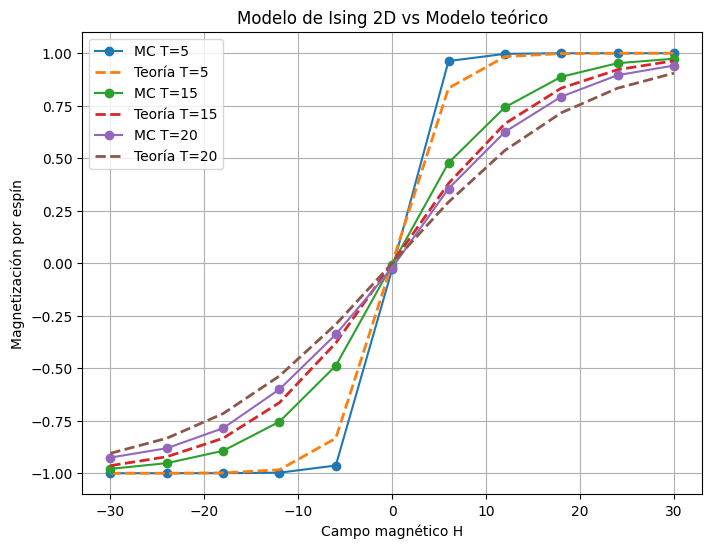

In [6]:
#Parametros (Mucho tiempo de computo cuando L>15)
L = 12
N = L * L

#Trabajando en unidades naturales
J = 1.0
kB = 1.0

# Pasos Monte Carlo y de equilibracion (de esto depende el tiempo de computo y la precision del modelo)
n_eq = 100
n_mc = 100

temperaturas = [5, 15, 20]

Hs = np.linspace(-30, 30, 11)

#Graficando con los parametros y datos del ejercicio
plt.figure(figsize=(8,6))
for T in temperaturas:

    print(f"Calculando T = {T}")

    Ms = []

    red = setear_malla(L) #usamos la funcion que creamos al principio

    for H in Hs:

        m = magnetizacion(red, T, H)

        Ms.append(m)

    # Monte Carlo
    plt.plot(
        Hs,
        Ms,
        'o-',
        label=f"MC T={T}"
    )

    # Solución analítica paramagnética
    m_teo = np.tanh(Hs / T)

    plt.plot(
        Hs,
        m_teo,
        '--',
        linewidth=2,
        label=f"Teoría T={T}"
    )

plt.xlabel("Campo magnético H")
plt.ylabel("Magnetización por espín")
plt.title("Modelo de Ising 2D vs Modelo teórico")
plt.grid(True)
plt.legend()
plt.show()

# **Comparación con la teoría analítica: caso sin interacción (J=0)**

Aquí cada espín es independiente.

La función de partición de un espín es

$$Z_1 = e^{βH}+e^{−βH}=2cosh(βH)
$$
Para N espines:
$$Z=(2cosh(βH))^N
$$
La magnetización es

$$ M=Ntanh(βH) $$

o por espín
$$
m=tanh(H/T)
$$
(en unidades naturales $ k_B=1 $).

Este resultado es exactamente el comportamiento paramagnético clásico.

La curva teórica es
$$m=tanh(TH​)$$

La temperatura crítica es
$$T_c = \frac{2J} {ln(1+\sqrt{2})}
$$

En unidades $J=1$:
$$T_c ≈2.269$$

Debajo de $T_c$ aparece magnetización espontánea, por encima de $T_c$, desaparece.

Para $H\neq0$, no existe una solución cerrada tan simple, por lo que Monte Carlo es el método estándar.

Para las temperaturas dadas ($T=5,15,2$0) son muy superiores a la temperatura crítica del modelo de Ising 2D. Por tanto, el sistema estará siempre en la fase paramagnética y la simulación se aproxima decentemente bien al modelo clásico analítico dado por la función tanh.

La precisión del modelo depende claramente de las dimensiones de la red, el número de pasos de Monte Carlo y número de pasos de equilibración ($n_mc$ y $n_eq$, respectivamente).